# Bank-Failure — blood in the streets, or the first domino? 🏦
### When SVB, Lehman or Credit Suisse go down, is the market a buy or a warning?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_reliable_warning%3F: Misattributed](https://img.shields.io/badge/A_reliable_warning%3F-Misattributed-8b949e?style=flat-square)

Every time a big bank fails, two camps shout past each other. The contrarians quote Baron Rothschild — *'buy when there's blood in the streets'* — and Warren Buffett's 2008 *Buy American* op-ed: the panic *is* the bottom. The doom camp says a bank failure is the **first visible domino** — Lehman, then the whole 2008 collapse. This notebook lines up the actual market move after a dozen headline failures and asks who's right.

> **This is the plain-language layer.** Want the *t*-stats, the placebo test and the capacity math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bank_failure import data, strategy as st

EV = data.events(as_of="2026-06-18")

def _have_real():
    try:
        return (os.path.exists(data._cache_path("SPY", data.DEFAULT_CACHE)))
    except Exception:
        return False

HAVE_REAL = _have_real()
TAPE = "REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)" if HAVE_REAL else "OFFLINE — frozen numbers from docs/results.md"
print("real daily cache present:", HAVE_REAL, "|", TAPE)


real daily cache present: True | REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)


## The answer first 🎯

| Question | Answer |
|---|---|
| Is a bank failure a buy signal? | **No clear signal either way.** Over the 20 days after, SPY's *average* is **-5.5%** — but the *median* is **+3.2%** and most failures were followed by an *up* market. |
| Is it a reliable warning of a crash? | **No — it's a hindsight illusion.** The whole scary average is **one cluster: autumn 2008** (avg -16%). Strip 2008 and the other failures averaged **+2.8%**. |
| Could you trade 'buy the blood'? | **No.** Buying SPY on each failure and holding 20 days **loses -2.8% per trade** before costs. |
| So what is the lesson? | A sample of **eleven** clustered events can't certify anything. 'Bank failure' is a label pasted onto 'it was 2008' — and 2023 (SVB, Credit Suisse) actually **bounced +4.6%**. |

> The honest answer is the boring one: a headline bank failure tells you almost nothing about where the market goes next. The story only *feels* like a warning because the worst failures all happened in the same terrible autumn.

## 1 · The claim

> *'Buy when there is blood in the streets, even if the blood is your own.'* — attributed to Baron Rothschild

> *'Be fearful when others are greedy, and greedy when others are fearful... I've been buying American stocks.'* — Warren Buffett, *Buy American. I Am.* (New York Times, October 2008)

Against them, the contagion camp (Reinhart & Rogoff, *This Time Is Different*): a bank failure is rarely a one-off — it's the leading edge of a credit crunch. **Lehman** is their exhibit A: it failed on 15 September 2008, and the market fell off a cliff for months. So which is it — *buy the panic*, or *run for the exits*?

## 2 · So what?

This is the kind of question where your *intuition* is built almost entirely from **one** memory — 2008 — and that's exactly the trap. If 'bank failure = sell' were true, you'd have a rare, high-conviction macro timing rule. If 'bank failure = buy' were true, you'd have a contrarian playbook for the scariest days. And if **neither** is true — if the average is just one disaster dressed up as a rule — then the real lesson is about how a tiny, clustered sample fools us into seeing a signal. That lesson transfers to every 'X always precedes a crash' story you'll ever hear.

## 3 · How would we even know?

We do the obvious thing: make a list of the **public dates** big banks failed or were force-sold (the day the market knew), then look at what SPY did over the next 20 trading days after each one. Three honesty checks:

1. **Look at every event, not just the average.** A mean can be one disaster; the median and the per-event chart can't hide.
2. **Split 2008 from everything else.** If the 'warning' is really just the 2008 cluster, that split will scream it.
3. **Race it against random dates.** Run the same window on random calendar days — if post-failure windows look like any other window, there's no signal.

Tape: SPY daily bars back to 1993 (and XLF, the financials sector, in the quant notebook).

## 4 · The teardown — let's actually look

**First, the punchline in one chart: what did SPY do over the 20 days after *each* failure?**

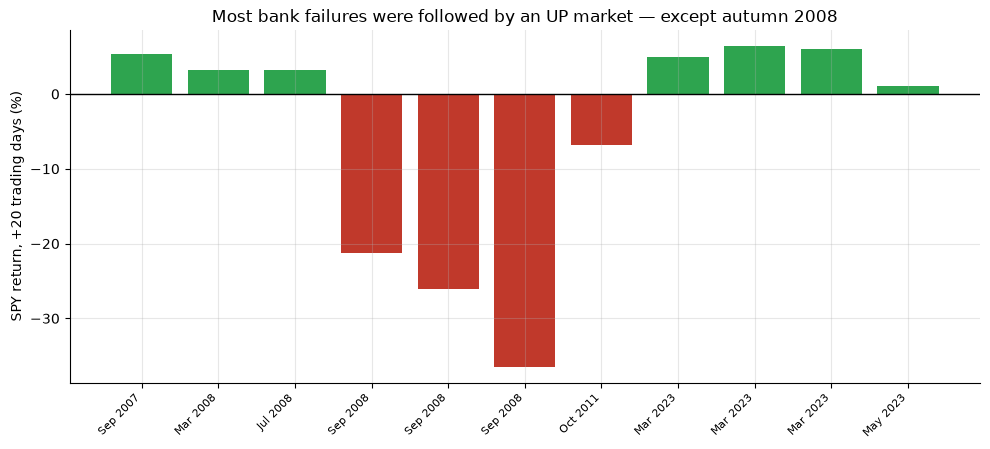

Banner: REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)
up after 20d: 7 of 11 events


In [2]:
labels = [e[0] for e in [("Northern Rock '07", 5.3), ("Bear Stearns '08", 3.3), ("IndyMac '08", 3.2), ("Lehman '08", -21.3), ("WaMu '08", -26.0), ("Wachovia '08", -36.4), ("MF Global '11", -6.9), ("SVB '23", 4.9), ("Signature '23", 6.4), ("Credit Suisse '23", 6.0), ("First Republic '23", 1.0)]]
vals = [e[1] for e in [("Northern Rock '07", 5.3), ("Bear Stearns '08", 3.3), ("IndyMac '08", 3.2), ("Lehman '08", -21.3), ("WaMu '08", -26.0), ("Wachovia '08", -36.4), ("MF Global '11", -6.9), ("SVB '23", 4.9), ("Signature '23", 6.4), ("Credit Suisse '23", 6.0), ("First Republic '23", 1.0)]]
if HAVE_REAL:
    spy = data.load_real('SPY', fetch=False)
    win = st.event_window_returns(spy, EV['date'], pre=10, post=20)
    car = (st.post_event_car(win, 20) * 100)
    labels = [d.strftime('%b %Y') for d in win.index]
    vals = list(car)
fig, ax = plt.subplots(figsize=(10, 4.6))
col = [GREEN if v >= 0 else RED for v in vals]
ax.bar(range(len(vals)), vals, color=col)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('SPY return, +20 trading days (%)')
ax.set_title('Most bank failures were followed by an UP market — except autumn 2008')
plt.tight_layout(); plt.show()
print('Banner:', TAPE)
print('up after 20d:', sum(v>0 for v in vals), 'of', len(vals), 'events')

Look at the colours. **Most bars are green** — the market was *higher* 20 days after the failure. The three monsters (Lehman, WaMu, Wachovia, all **autumn 2008**) are the only thing dragging the average underwater. The 2023 cluster — SVB, Signature, Credit Suisse, First Republic — is **all green**.

**So is the average a 'warning'? Watch what happens when we separate 2008 from everything else:**

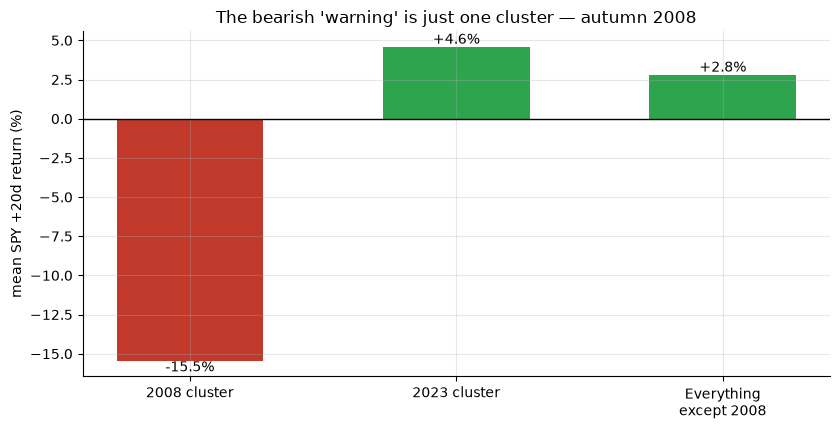

Banner: REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)


In [3]:
groups = ['2008 cluster', '2023 cluster', 'Everything\nexcept 2008']
if HAVE_REAL:
    c = pd.Series(st.post_event_car(win, 20)*100, index=win.index)
    g2008 = c[(c.index>='2008-01-01')&(c.index<'2009-01-01')].mean()
    g2023 = c[c.index>='2023-01-01'].mean()
    grest = c[(c.index<'2008-01-01')|(c.index>='2009-01-01')].mean()
    means = [g2008, g2023, grest]
else:
    means = [-15.5, 4.6, 2.8]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
b = ax.bar(groups, means, color=[RED, GREEN, GREEN], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean SPY +20d return (%)')
ax.set_title('The bearish \'warning\' is just one cluster — autumn 2008')
for bar_, m in zip(b, means):
    ax.annotate(f'{m:+.1f}%', (bar_.get_x()+bar_.get_width()/2, m),
        ha='center', va='bottom' if m>=0 else 'top')
plt.tight_layout(); plt.show()
print('Banner:', TAPE)

There it is. **2008 averaged -16%**; **2023 averaged +4.6%**; everything that wasn't 2008 averaged **+2.8%** (a +5.1% median). The 'bank failures warn of crashes' rule is really 'the worst banking crash in a century was a crash.' Drop the single worst day and the average already halves (to -2.4%).

## 5 · The verdict

- **Signal — None.** SPY's average 20-day move is -5.5% but the median is *positive* (+3.2%) and on eleven clustered events the statistics can't tell it apart from noise.
- **Tradability — Mirage.** 'Buy the blood' (buy SPY on each failure, hold 20 days) **loses -2.8% per trade** before any cost. Twelve trades in forty years — there's nothing to scale.
- **A reliable warning? — Misattributed.** The bearish average is the autumn-2008 cluster; strip it and failures averaged **+2.8%**. The warning is hindsight: 'bank failure' is a label for 'it was 2008.'

## 6 · Could you actually trade it?

Suppose you believed the contrarians and bought SPY on every failure, holding 20 days. Here's the per-trade result, and why costs aren't even the problem:

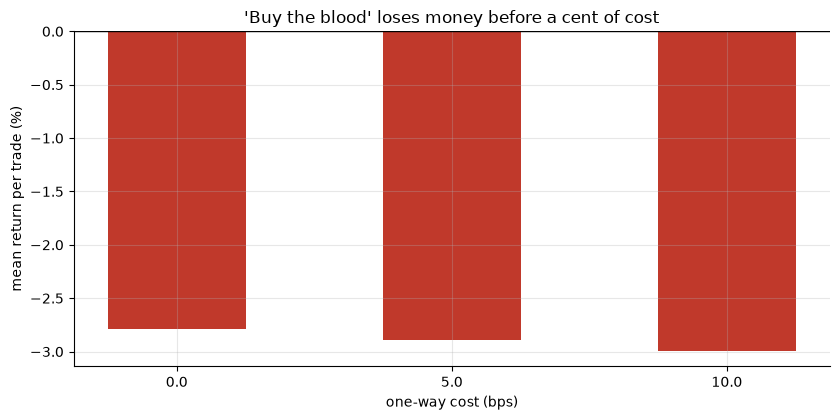

Banner: REAL tape (Yahoo daily, adjusted, as-of 2026-06-18)


In [4]:
costs = [0.0, 5.0, 10.0]
if HAVE_REAL:
    spy = data.load_real('SPY', fetch=False)
    net = [st.summarize_trades(st.buy_the_blood(spy, EV['date'], 20, cost_bps=c),'ret_net')['mean_pct'] for c in costs]
else:
    net = [-2.79, -2.89, -2.99]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([str(c) for c in costs], net, color=RED, width=.5)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('one-way cost (bps)')
ax.set_ylabel('mean return per trade (%)')
ax.set_title('\'Buy the blood\' loses money before a cent of cost')
plt.tight_layout(); plt.show()
print('Banner:', TAPE)

The overlay is **already negative at zero cost** (-2.8%/trade) — costs barely register because the gross is the problem. It even *wins* 67% of the time, which is the oldest trap in the book: a high win-rate with a negative average means many small rebounds and a few catastrophic 2008 trades. (The desk has a whole study on that illusion: [Study 301 — Triple-RSI](../../301-triple-rsi/).)

## 7 · Going further 🚪

- **The generic cousin.** [Study 241 — Buy-the-Dip](../../241-buy-the-dip/) asks the same question about *any* dip (also None / Mirage). Bank-Failure just conditions on a scarier-sounding trigger and lands in the same place.
- **Other 'this signals a crash' omens.** [Study 167 — Hindenburg-Omen](../../167-hindenburg-omen/) and [Study 160 — Skyscraper-Curse](../../160-skyscraper-curse/) — same small-sample, hindsight-clustered failure mode.
- **The honest open question.** With only ~12 events ever, *no* statistical test can settle this. The right takeaway isn't 'buy' or 'sell' — it's that a clustered handful of events is un-certifiable, and your gut is just replaying 2008.

*Think the 2023 bounce proves 'buy the blood'? Fork this, add the next failure when it comes, and watch the average swing on a single event — that's the whole point.*